# 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder()
from sklearn.model_selection import RandomizedSearchCV, train_test_split


# 2. Load the dataset (with features)

In [36]:
df = pd.read_csv("../data/ble_data_FE_labeled.csv")

In [37]:
df.head()

,time,count_beacon_1,count_beacon_2,count_beacon_3,count_beacon_4,count_beacon_5,count_beacon_6,count_beacon_7,count_beacon_8,count_beacon_9,...,sd_rssi_b21,mean_rssi_b22,sd_rssi_b22,mean_rssi_b23,sd_rssi_b23,mean_rssi_b24,sd_rssi_b24,mean_rssi_b25,sd_rssi_b25,location
0,2023-04-10 14:21:40,214,68,34,17,68,34,17,17,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen
1,2023-04-10 14:21:50,68,0,34,17,0,67,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
2,2023-04-10 14:22:00,136,0,0,51,47,51,51,34,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
3,2023-04-10 14:22:10,238,0,0,0,55,34,17,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
4,2023-04-10 14:22:20,17,0,0,0,0,34,17,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen


In [38]:
df = df.drop(columns="time")
df.head()

,count_beacon_1,count_beacon_2,count_beacon_3,count_beacon_4,count_beacon_5,count_beacon_6,count_beacon_7,count_beacon_8,count_beacon_9,count_beacon_10,...,sd_rssi_b21,mean_rssi_b22,sd_rssi_b22,mean_rssi_b23,sd_rssi_b23,mean_rssi_b24,sd_rssi_b24,mean_rssi_b25,sd_rssi_b25,location
0,214,68,34,17,68,34,17,17,17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen
1,68,0,34,17,0,67,0,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
2,136,0,0,51,47,51,51,34,34,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
3,238,0,0,0,55,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
4,17,0,0,0,0,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen


Text(0, 0.5, 'Count')

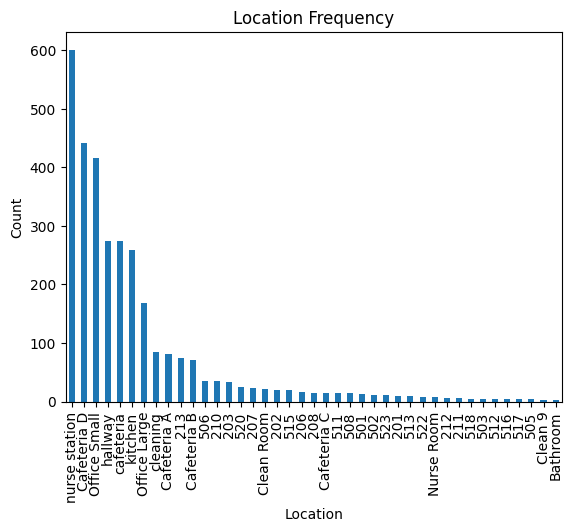

In [39]:
df['location'].value_counts().plot(kind='bar')
plt.title('Location Frequency')
plt.xlabel('Location')
plt.ylabel('Count')

In [40]:
X = df.drop(columns='location')
X.head()

,count_beacon_1,count_beacon_2,count_beacon_3,count_beacon_4,count_beacon_5,count_beacon_6,count_beacon_7,count_beacon_8,count_beacon_9,count_beacon_10,...,mean_rssi_b21,sd_rssi_b21,mean_rssi_b22,sd_rssi_b22,mean_rssi_b23,sd_rssi_b23,mean_rssi_b24,sd_rssi_b24,mean_rssi_b25,sd_rssi_b25
0,214,68,34,17,68,34,17,17,17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,68,0,34,17,0,67,0,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,136,0,0,51,47,51,51,34,34,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,238,0,0,0,55,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17,0,0,0,0,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


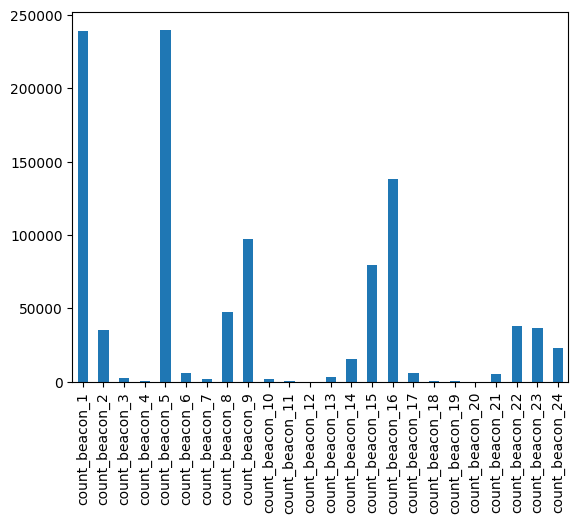

In [41]:
feature_count = X[X.columns[0:24]].sum()
feature_count.plot(kind='bar')
plt.show()

# 3. Train a random forest model

In [42]:
y = df['location']
y.head()

0      kitchen
1    cafeteria
2    cafeteria
3    cafeteria
4      kitchen
Name: location, dtype: object

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
split_idx = int(0.7 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y_encoded[:split_idx]
y_test  = y_encoded[split_idx:]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

TypeError: LabelEncoder.fit_transform() takes 2 positional arguments but 3 were given

In [77]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"F1 score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.39
F1 score: 0.35
Precision: 0.32
Recall: 0.39


c:\Users\laber\MASc\Thunderbolts-W\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [73]:
labels = df['location'].unique()
cm = confusion_matrix(y_test, y_pred, labels=labels)

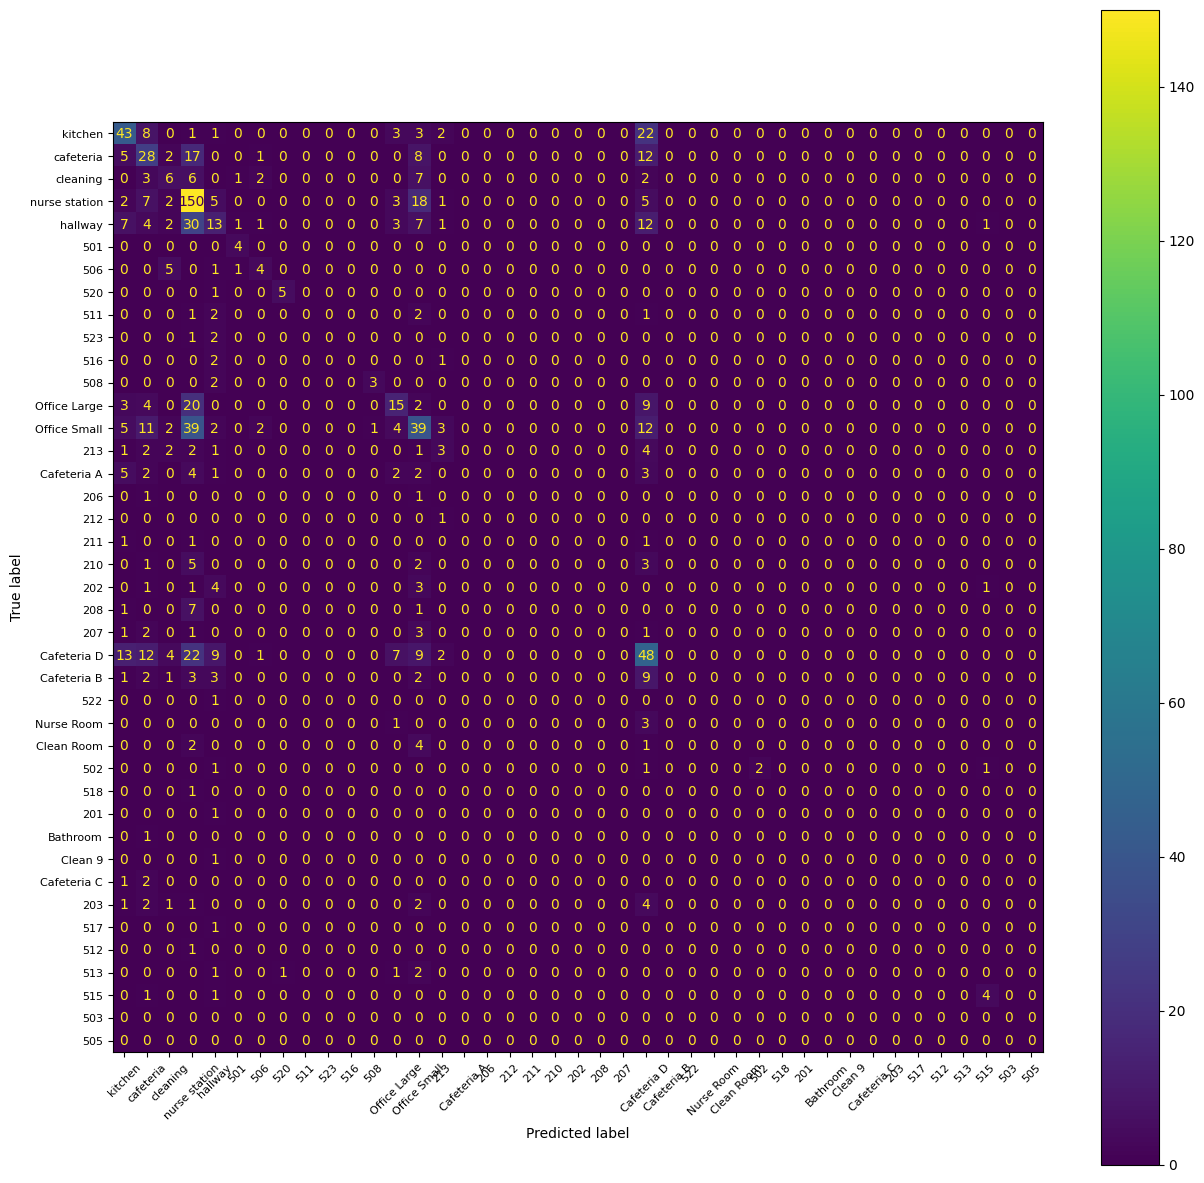

In [76]:
fig, ax = plt.subplots(figsize=(15, 15)) 
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    labels=labels,
    display_labels=labels, 
    xticks_rotation=45,
    ax=ax              
)

plt.setp(ax.get_xticklabels(), fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)

plt.show()

In [ ]:
y_proba = pipeline.predict_proba(X_test)

top_k = 3
top_k_preds = np.argsort(y_proba, axis=1)[:, -top_k:]

top_k_accuracy = np.mean([
    y_test[i] in top_k_preds[i]
    for i in range(len(y_test))
])

print(f"Top-{top_k} Accuracy: {top_k_accuracy:.3f}")